In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import defs
import re



In [76]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_colwidth', 20)

In [77]:
df = pd.read_csv('../data/_data.csv', encoding='utf-8')
# df.head(5)

In [78]:
df = df.drop(columns=['Unnamed: 0'])
df = df.reset_index(drop=True)


In [79]:
# for column in df.columns.tolist(): 
#     print (column)
#     print (df[column].value_counts(dropna=False))

In [80]:
df.columns=['Ad_ID', 'Number_of_rooms', 'Type', 'Metro', 'Address',
 'Area_m2', 'Building', 'Parking', 'Price', 'Phones', 'Description',
 'Renovation', 'Room_area_m2', 'Balcony', 'Windows', 'Bathroom',
 'Children/pets_allowed', 'Additional', 'Residential_complex_name',
 'Building_series', 'Ceiling_height_m', 'Elevator', 'Garbage_chute',
 'Ad_link']
ya_i_columns = ['Ad_ID', 'Description', 'Renovation', 'Room_area_m2', 'Balcony', 'Windows', 'Bathroom', 'Children/pets_allowed']

In [81]:
# Обработать колонки:
# Description	
# (+) Renovation	
# (+) Room_area_m2	
# (+) Balcony	
# (+) Windows	
# (+) Bathroom	
# (+) Children/pets_allowed
# Очистить от NaN
# Добавить Dummy-кодирование 

def extract_numbers(text):
    if pd.isna(text):
        return []
    numbers_str = re.findall(r'\d+(?:[.,]\d+)?', str(text))
    return [float(x.replace(',', '.')) for x in numbers_str]

def sum_func(text):
    if pd.isna(text):
        return 0
    numbers = re.findall(r'\((\d+)\)', text)
    return sum(int(num) for num in numbers)

ya_i_df = df[ya_i_columns]

ya_i_df['Renovation'] = ya_i_df['Renovation']

ya_i_df['Room_area_m2'] = ya_i_df['Room_area_m2'].apply(extract_numbers)

ya_i_df['Balcony'] = ya_i_df['Balcony'].str.replace(r'\s*\(\d+\)', '', regex=True)
ya_i_df['Balcony_count'] = ya_i_df['Balcony'].apply(sum_func)

ya_i_df['Bathroom'] = ya_i_df['Bathroom'].str.replace(r'\s*\(\d+\)', '', regex=True)
ya_i_df['Bathroom_count'] = ya_i_df['Bathroom'].apply(sum_func)

# ya_i_df['Description']

# ya_i_df['Renovation'].unique()


In [82]:
df['Renovation'] = df['Renovation']

df['Room_area_m2'] = df['Room_area_m2'].apply(extract_numbers)

df['Balcony_count'] = df['Balcony'].apply(sum_func)
df['Balcony'] = df['Balcony'].str.replace(r'\s*\(\d+\)', '', regex=True)

df['Bathroom_count'] = df['Bathroom'].apply(sum_func)
df['Bathroom'] = df['Bathroom'].str.replace(r'\s*\(\d+\)', '', regex=True)

# df['Bathroom_count']

In [83]:
df['Number_of_rooms_int'] = df['Number_of_rooms'].apply(lambda x : defs.cutter(x,','))
df['Type of room'] = df['Number_of_rooms'].apply(lambda x : defs.cutter(x,',', index_start=1, index_end= None))

In [84]:
df= df.drop('Number_of_rooms', axis=1)

In [85]:
df['extra_money'] = df['Price'].apply(lambda x: defs.cutter(x,'/', index_start=1, index_end = None))
df['Price'] = df['Price'].apply(lambda x: defs.cutter(x,'/'))


In [86]:
df['Price']=df['Price'].apply(defs.re_money)

In [87]:
df['Full_area']= df['Area_m2'].apply(lambda x: defs.cutter(x,'/')).astype(float)
df['Rooms_area'] = df['Area_m2'].apply(lambda x: x.split('/')[1:] if len(x.split('/'))>1 else None)
df=df.drop('Area_m2', axis=1)

In [88]:
df['Float_floor']= df["Building"].apply(lambda x: defs.extract_pattern(x, pattern = r'\d+/\d+')).apply(lambda x: defs.cutter(x, '/'))
df['Height_building']= df["Building"].apply(lambda x: defs.extract_pattern(x, pattern = r'\d+/\d+')).apply(lambda x: defs.cutter(x, '/', index_start=1, index_end=None))
df['Building_type'] = df['Building'].apply(lambda x: defs.cutter(x, ',', index_start=1, index_end=None))

In [89]:
df = df.drop('Building', axis=1)


In [90]:
# df

In [91]:
df = df[~df['Address'].str.lower().str.startswith('санкт-петербург', na=False)]

In [92]:
# df["Garbage_chute"] = df["Garbage_chute"].replace({"Да":1, "Нет":0})
df["Garbage_chute(yes)"] = df["Garbage_chute"].eq("Да")
df["Garbage_chute(no)"] = df["Garbage_chute"].eq("Нет")

df["Garbage_chute(yes)"] = df["Garbage_chute(yes)"].astype(int)
df["Garbage_chute(no)"] = df["Garbage_chute(no)"].astype(int)

In [93]:
df.loc[df["Ceiling_height_m"] > 100, "Ceiling_height_m"] /= 100
df.loc[df["Ceiling_height_m"] > 24.9, "Ceiling_height_m"] /= 10

df["Ceiling_height_m"] = df["Ceiling_height_m"][(df["Ceiling_height_m"] > 2.4) & (df["Ceiling_height_m"] < 6)]

In [94]:
df["pass_elev"] = df["Elevator"].str.extract(r"Пасс\s*\((\d+)\)").fillna(0).astype(int)
df["cargo_elev"] = df["Elevator"].str.extract(r"Груз\s*\((\d+)\)").fillna(0).astype(int)
df["elevator_more_2"] = (df["pass_elev"]+df["cargo_elev"] >= 2).astype(int)


In [95]:
df = df.drop(["Elevator", "Residential_complex_name", "Building_series", "Garbage_chute"], axis=1)

In [96]:
# df.info()

## Распределение количества кваритир по количеству комнат

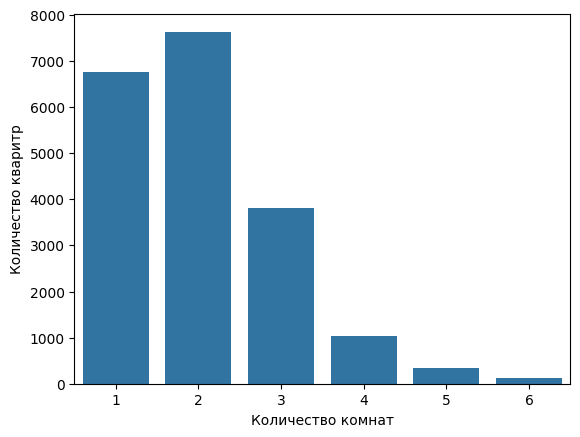

In [97]:

fig, ax = plt.subplots()
sns.barplot(data = df.groupby('Number_of_rooms_int', as_index=False).count() , x ='Number_of_rooms_int', y = 'Ad_ID' )
ax.set_xlabel('Количество комнат')
ax.set_ylabel('Количество кваритр')
plt.show()


In [98]:
#df.to_csv('../data/data_v0_1.csv', encoding='utf-8')

## Зависимость цены от площади

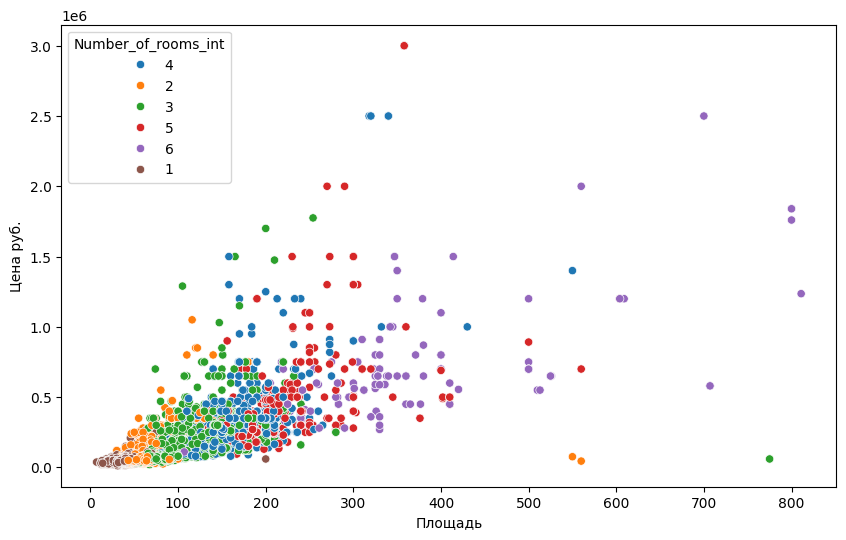

In [99]:
fig, ax = plt.subplots(figsize = (10,6))
sns.scatterplot(df, x = 'Full_area', y='Price', hue = 'Number_of_rooms_int')

ax.set_xlabel('Площадь')
ax.set_ylabel('Цена руб.')
plt.show()

## Зависимость цены от станции метро 

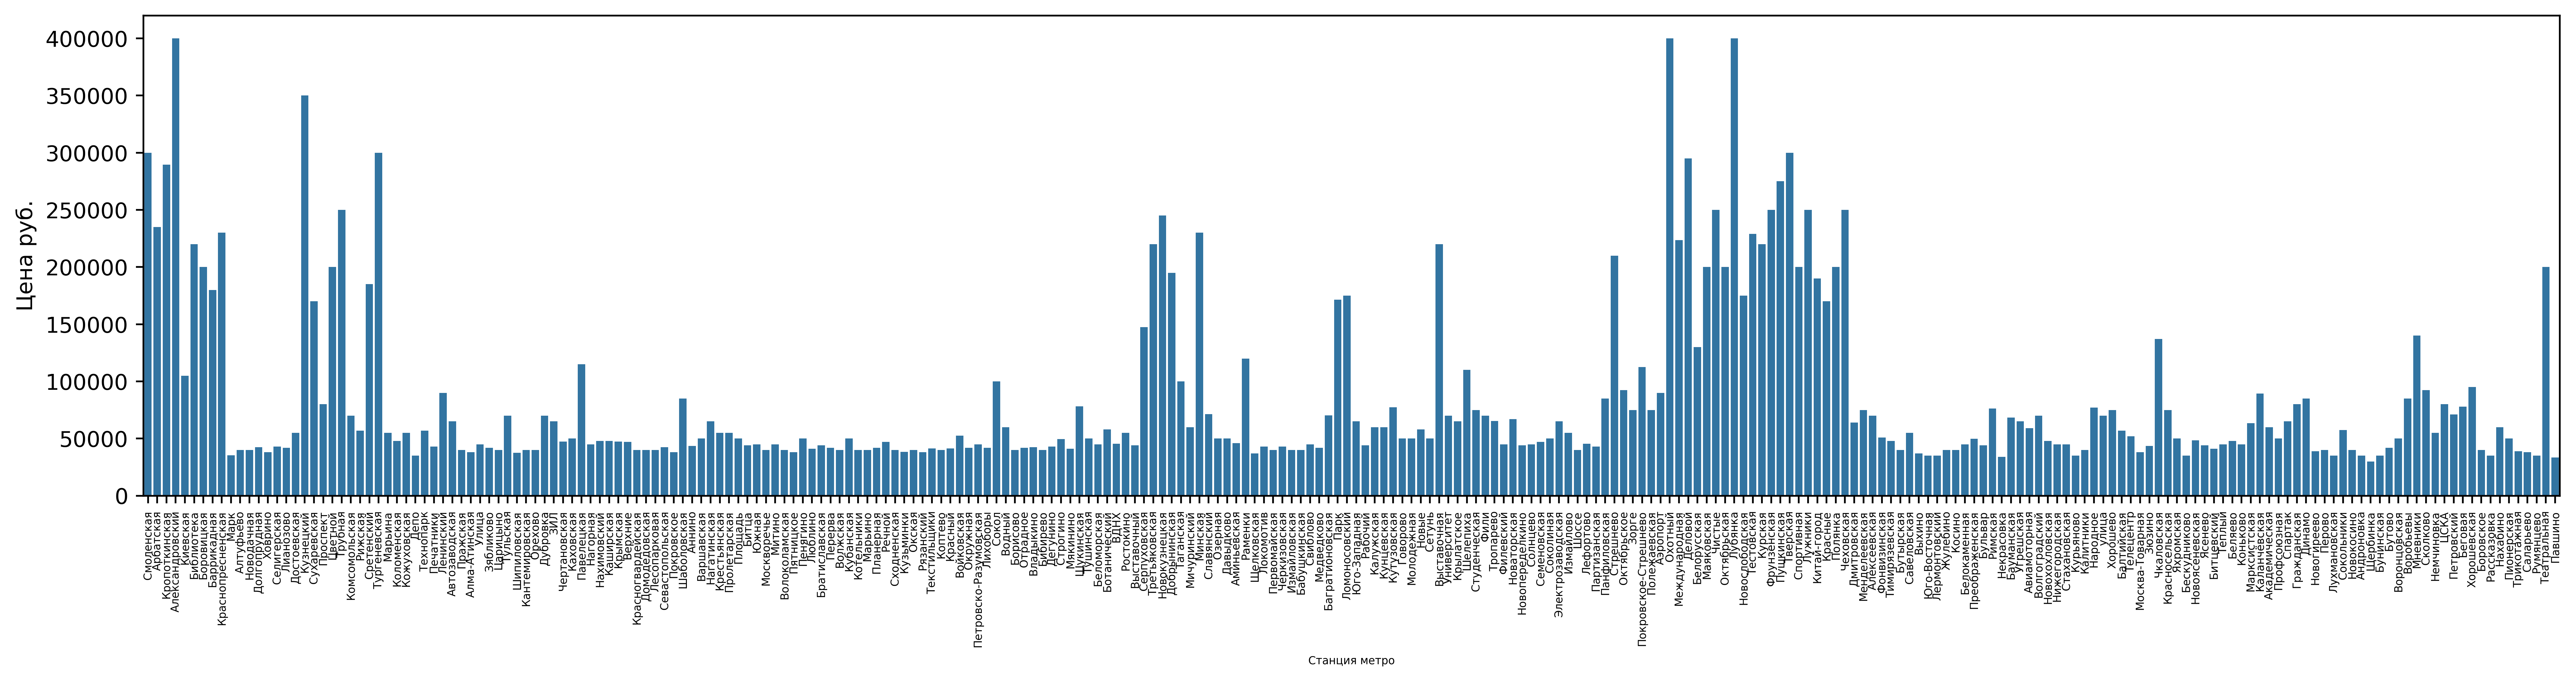

In [100]:
df_metro = df['Metro'].apply(lambda x : defs.cutter(x,' ', index_start= 1, index_end=2))
fig, ax = plt.subplots(figsize = (20,4), dpi = 500)
sns.barplot(df, x = df_metro, y='Price', errorbar = None, estimator= 'median')
plt.xticks(rotation = 90)
ax.tick_params(axis='x', labelsize=5)
ax.set_xlabel('Станция метро',size=5)
ax.set_ylabel('Цена руб.')
plt.show()

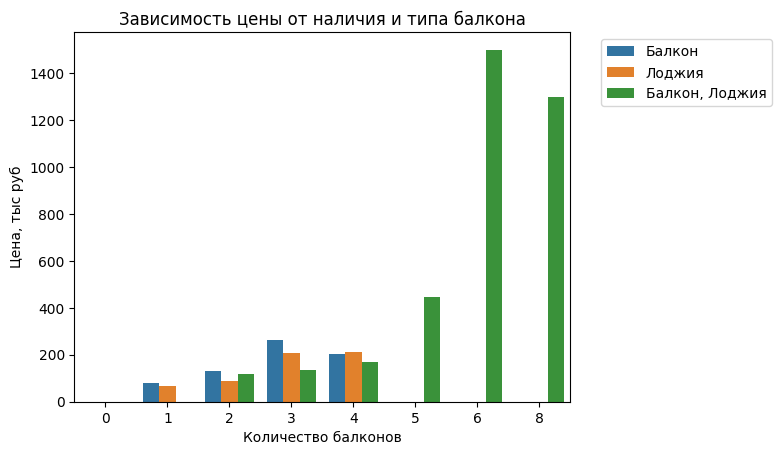

<Figure size 768x576 with 0 Axes>

In [101]:
ax = sns.barplot(
    data=df,
    x='Balcony_count',
    y=df['Price']/1000,
    hue='Balcony',
    errorbar=None
)

ax.set(
    title='Зависимость цены от наличия и типа балкона',
    xlabel='Количество балконов',
    ylabel='Цена, тыс руб'
    )

ax.legend(
    bbox_to_anchor=(1.42, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

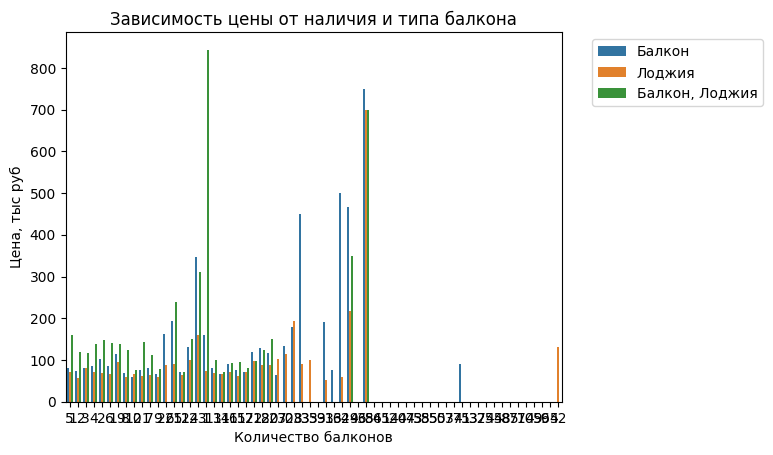

<Figure size 768x576 with 0 Axes>

In [102]:
ax = sns.barplot(
    data=df,
    x='Float_floor',
    y=df['Price']/1000,
    hue='Balcony',
    errorbar=None
)

ax.set(
    title='Зависимость цены от наличия и типа балкона',
    xlabel='Количество балконов',
    ylabel='Цена, тыс руб'
    )

ax.legend(
    bbox_to_anchor=(1.42, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

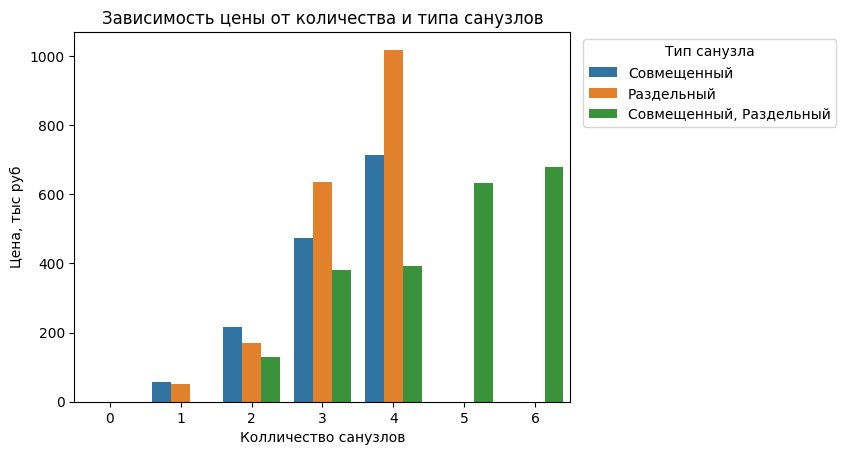

<Figure size 768x576 with 0 Axes>

In [103]:
ax = sns.barplot(
    data=df,
    x='Bathroom_count',
    y=df['Price']/1000,
    hue='Bathroom',
    errorbar=None
)

ax.set(
    title='Зависимость цены от количества и типа санузлов',
    xlabel='Колличество санузлов',
    ylabel='Цена, тыс руб',
    )

ax.legend(
    title='Тип санузла',
    bbox_to_anchor=(1.55, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

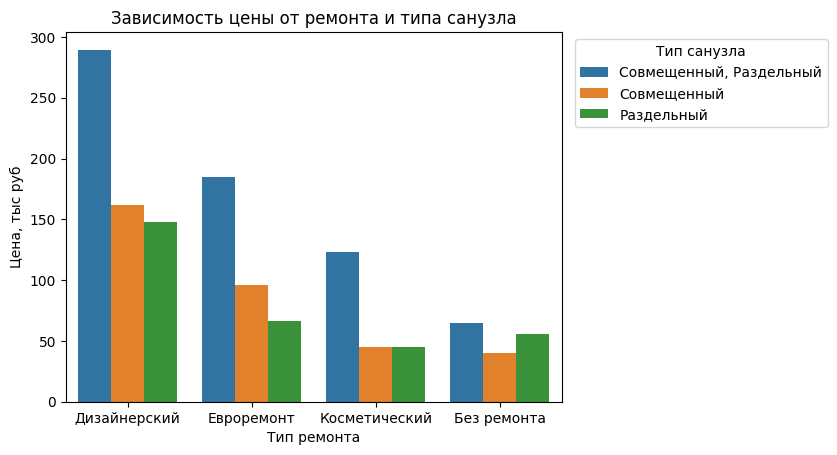

<Figure size 768x576 with 0 Axes>

In [104]:
ax = sns.barplot(
    data=df,
    x='Renovation',
    y=df['Price']/1000,
    hue='Bathroom',
    errorbar=None
)

ax.set(
    title='Зависимость цены от ремонта и типа санузла',
    xlabel='Тип ремонта',
    ylabel='Цена, тыс руб',
    )

ax.legend(
    title='Тип санузла',
    bbox_to_anchor=(1.55, 1),
    loc="upper right"
)

plt.figure(dpi=120)

plt.show()

## Тепловая карта 

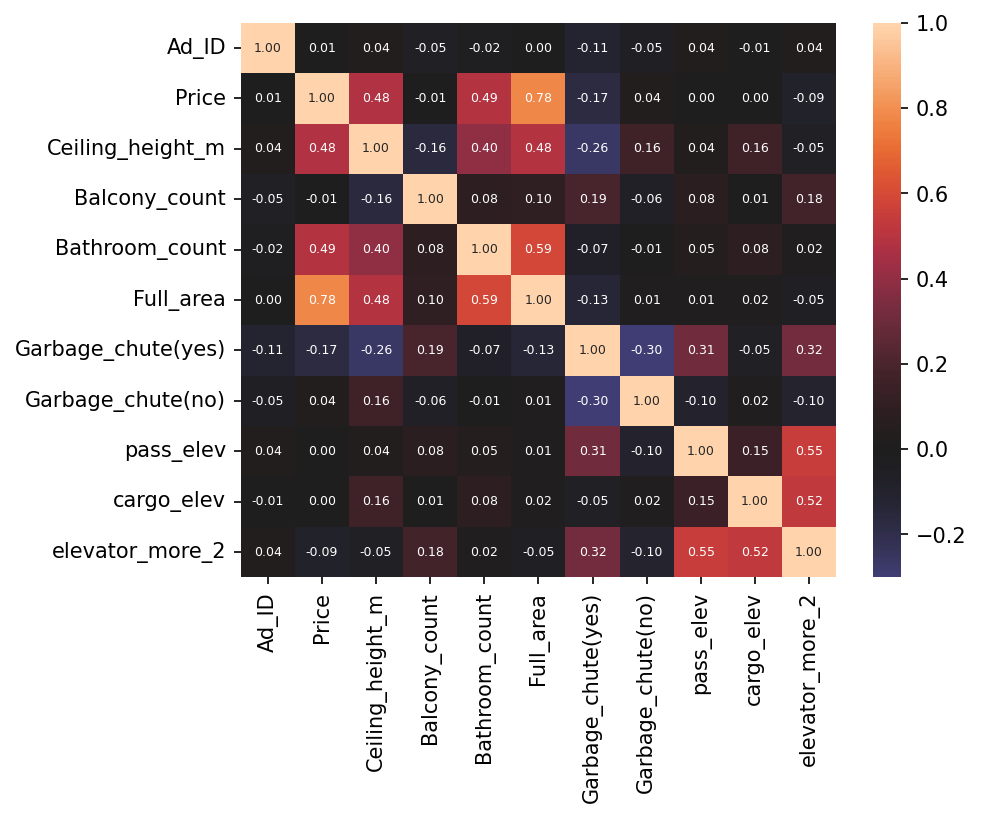

In [105]:
plt.figure(dpi=150)
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    center=0,
    fmt=".2f",
    annot_kws={'size': 6}
)

plt.show()

In [106]:
df["pass_elev"] = df["pass_elev"] [df["pass_elev"] < 12].astype(int)
df["cargo_elev"] = df["cargo_elev"][df["cargo_elev"] < 12].astype(int)
df["total_elev"] = df["pass_elev"] + df["cargo_elev"]


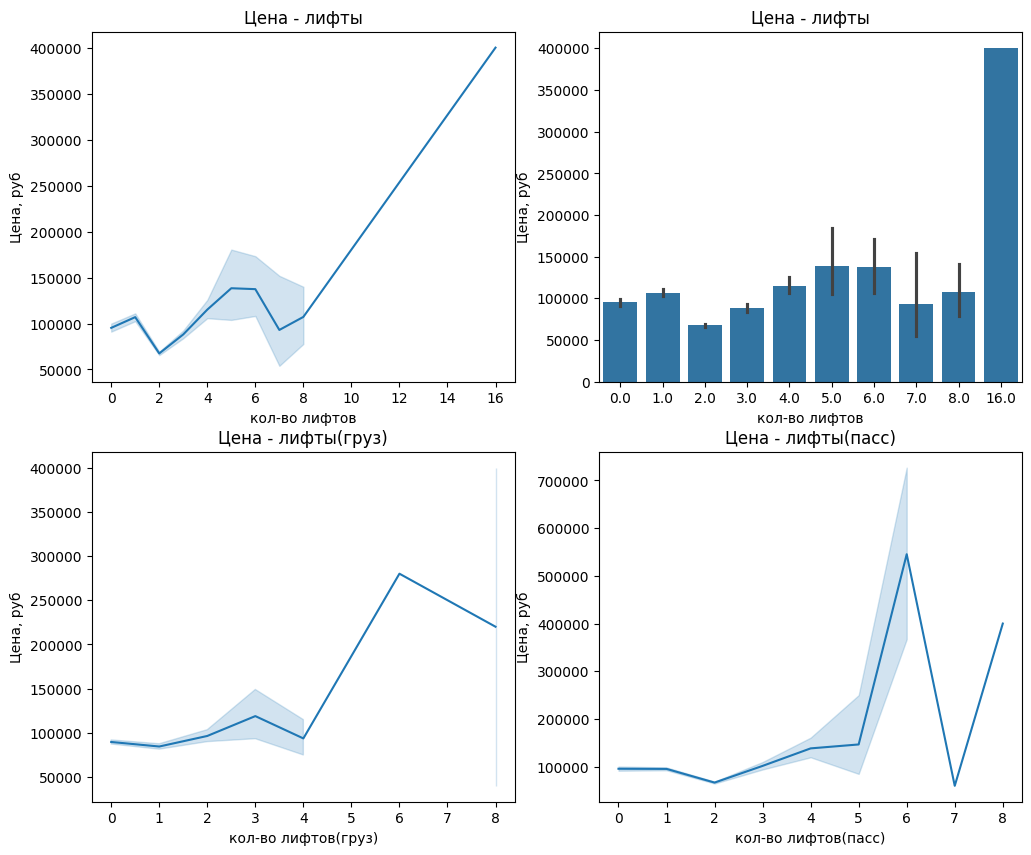

In [107]:
fix, axes = plt.subplots(2,2, figsize=(12,10))

sns.lineplot(data=df, x="total_elev", y="Price", ax=axes[0, 0])
sns.barplot(data=df, y="Price", x="total_elev", ax=axes[0, 1])

sns.lineplot(data=df, x="cargo_elev", y="Price", ax=axes[1, 0])
sns.lineplot(data=df, x="pass_elev", y="Price", ax=axes[1, 1])
axes[0, 0].set(title ='Цена - лифты' ,
    xlabel='кол-во лифтов',
    ylabel='Цена, руб'
               )
axes[0, 1].set(title ='Цена - лифты',
    xlabel='кол-во лифтов',
    ylabel='Цена, руб')
axes[1, 0].set(title ='Цена - лифты(груз)' ,
    xlabel='кол-во лифтов(груз)',
    ylabel='Цена, руб')
axes[1, 1].set(title ='Цена - лифты(пасс)' ,
    xlabel='кол-во лифтов(пасс)',
    ylabel='Цена, руб')
plt.show()

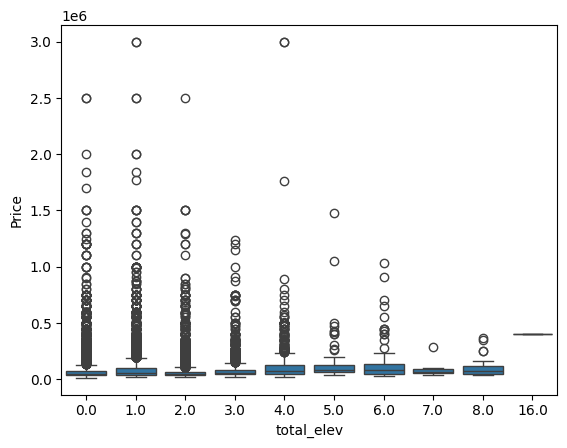

In [108]:
sns.boxplot(data=df, x="total_elev", y="Price")
plt.show()

In [109]:
df["trash_status"] = df["Garbage_chute(yes)"] + df["Garbage_chute(no)"]


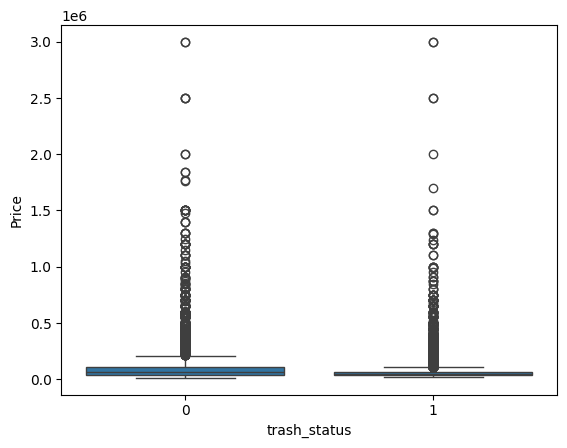

In [110]:
sns.boxplot(data=df, x="trash_status", y="Price")
plt.show()

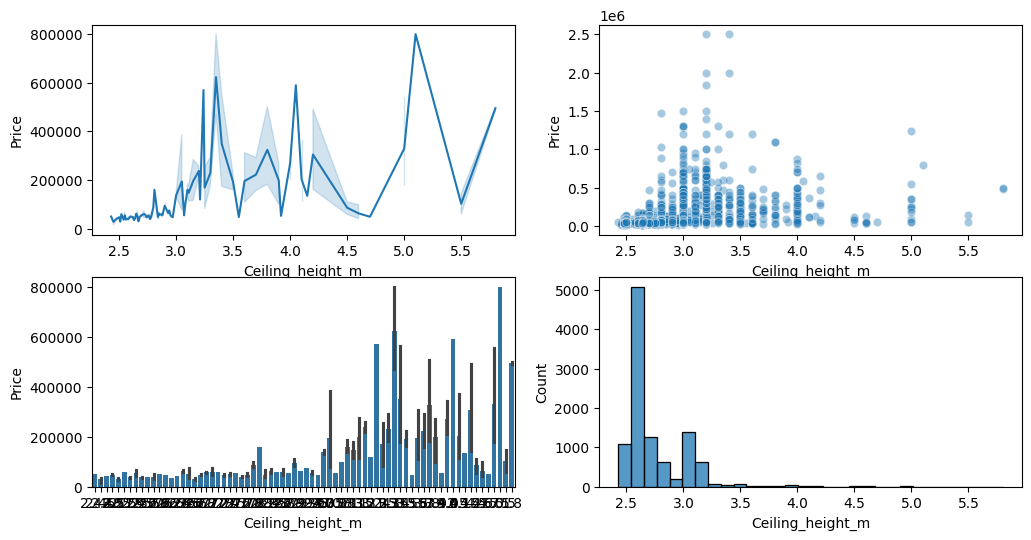

In [111]:
fix, axes = plt.subplots(2,2, figsize=(12,6))

sns.lineplot(data=df, x="Ceiling_height_m", y="Price", ax=axes[0, 0])
sns.scatterplot(data=df, x="Ceiling_height_m", y="Price", alpha=0.4, ax=axes[0, 1])
sns.histplot(df["Ceiling_height_m"], bins=30, ax=axes[1, 1])
sns.barplot(data=df, x="Ceiling_height_m", y="Price", ax=axes[1, 0])



plt.show()